# **Hospital Patient Records Analysis**

# Step 1: Import Required Libraries

In [ ]:


# Numerical Computation
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings('ignore')

# Display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)



# Insight
* NumPy is used for numerical computations and mathematical operations.
* Pandas helps in loading, cleaning, filtering, and analyzing structured data efficiently.
* Matplotlib is used for creating fundamental charts such as histograms, bar charts, scatter plots, and line graphs.
* Seaborn builds on Matplotlib to create more visually appealing and informative statistical visualizations.

# Step 2: Load the Dataset

In [ ]:
# Load CSV file
df = pd.read_csv("Hospital Patient .csv")

In [ ]:
# Display first 5 rows
print("First 5 Rows of the Dataset:")
display(df.head())

First 5 Rows of the Dataset:


,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


Insight
* The dataset has been successfully loaded into a Pandas DataFrame named df.
* Displaying the first five records helps verify that the dataset has been imported correctly.
* It also provides an initial understanding of the available features, data values, and overall structure before beginning the analysis.
* At this stage, we can identify whether the dataset contains numerical, categorical, or date-related columns that may require further preprocessing.

# Step 3: Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         984 non-null    int64 
 1   Age                984 non-null    int64 
 2   Gender             984 non-null    object
 3   Condition          984 non-null    object
 4   Medication         984 non-null    object
 5   Admission_Date     984 non-null    object
 6   Discharge_Date     984 non-null    object
 7   Patient_State      984 non-null    object
 8   Year_of_Admission  984 non-null    int64 
 9   Length_of_Stay     984 non-null    int64 
 10  Readmission        984 non-null    object
 11  Outcome            984 non-null    object
 12  Satisfaction       984 non-null    int64 
 13  Insurance_Claimed  984 non-null    object
 14  Total_Cost         984 non-null    int64 
dtypes: int64(6), object(9)
memory usage: 115.4+ KB


In [ ]:
df.shape

(984, 15)

In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ',
       'Admission_Date', 'Discharge_Date', 'Patient_State',
       'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome',
       'Satisfaction', 'Insurance_Claimed', 'Total_Cost'],
      dtype='object')

In [ ]:
df.describe()

,Patient_ID,Age,Year_of_Admission,Length_of_Stay,Satisfaction,Total_Cost
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,492.500000,53.754065,2023.460366,37.663618,3.598577,8367.479675
std,284.200633,14.941135,1.106926,19.595805,0.883002,7761.990976
min,1.000000,25.000000,2022.000000,1.000000,2.000000,100.000000
25%,246.750000,45.000000,2022.000000,21.000000,3.000000,1000.000000
50%,492.500000,55.000000,2023.000000,38.000000,4.000000,6000.000000
75%,738.250000,65.000000,2024.000000,54.250000,4.000000,15000.000000
max,984.000000,78.000000,2025.000000,76.000000,5.000000,25000.000000


# Insight
* The dataset overview provides a quick understanding of its structure and content.
* We checked the total number of rows and columns, viewed sample records, examined column names and data types, and generated summary statistics.
* This step helps identify the nature of each feature and prepares us for data cleaning and exploratory data analysis.

# Step 4: Data Cleaning

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Condition,0
Medication,0
Admission_Date,0
Discharge_Date,0
Patient_State,0
Year_of_Admission,0
Length_of_Stay,0


In [ ]:
df.dtypes

,0
Patient_ID,int64
Age,int64
Gender,object
Condition,object
Medication,object
Admission_Date,object
Discharge_Date,object
Patient_State,object
Year_of_Admission,int64
Length_of_Stay,int64


# Insight

* Missing values were checked to determine which columns require preprocessing.
* Data types were reviewed to ensure each feature is stored appropriately.

# Step 5: Data Type Conversion

In [ ]:
# Convert date columns into datetime format (if any)
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Display updated data types
print("Updated Data Types:")
display(df.dtypes)

Updated Data Types:


,0
Patient_ID,int64
Age,int64
Gender,object
Condition,object
Medication,object
Admission_Date,datetime64[ns]
Discharge_Date,datetime64[ns]
Patient_State,object
Year_of_Admission,int64
Length_of_Stay,int64


# Insight
* Date-related columns were converted to the datetime format to enable time-based analysis.
* Proper data types improve analysis accuracy and make operations such as filtering, grouping, and visualization more efficient.

# Step 6: Feature Engineering



In [ ]:
# Create Hospital Stay Days (if date columns exist)
if 'Date of Admission' in df.columns and 'Discharge Date' in df.columns:
    df['Hospital Stay (Days)'] = (
        df['Discharge Date'] - df['Date of Admission']
    ).dt.days

# Display newly created features
display(df.head())

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,2024-07-02,2024-12-02,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,2023-11-03,NaT,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,2025-02-01,2025-03-01,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,NaT,2024-06-01,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,2022-10-05,NaT,Mizoram,2022,10,No,Recovered,4,No,25000


# Insight
* Feature engineering creates new variables from existing data to improve analysis.
* Here, the Hospital Stay (Days) feature measures the duration of each patient's hospitalization, which can later be used to analyze treatment efficiency, billing patterns, and patient outcomes.
* If the required date columns are not present, this step is skipped automatically.

# Step 7: Descriptive Statistics

In [ ]:
# Numerical Statistics
print("Numerical Features Summary")
display(df.describe())


Numerical Features Summary


,Patient_ID,Age,Admission_Date,Discharge_Date,Year_of_Admission,Length_of_Stay,Satisfaction,Total_Cost
count,984.000000,984.000000,380,385,984.000000,984.000000,984.000000,984.000000
mean,492.500000,53.754065,2023-12-01 17:14:31.578947584,2023-12-29 23:03:53.766233856,2023.460366,37.663618,3.598577,8367.479675
min,1.000000,25.000000,2022-01-01 00:00:00,2022-01-02 00:00:00,2022.000000,1.000000,2.000000,100.000000
25%,246.750000,45.000000,2022-11-27 00:00:00,2023-02-04 00:00:00,2022.000000,21.000000,3.000000,1000.000000
50%,492.500000,55.000000,2023-11-08 00:00:00,2023-12-06 00:00:00,2023.000000,38.000000,4.000000,6000.000000
75%,738.250000,65.000000,2024-12-12 00:00:00,2024-11-11 00:00:00,2024.000000,54.250000,4.000000,15000.000000
max,984.000000,78.000000,2025-12-11 00:00:00,2026-11-02 00:00:00,2025.000000,76.000000,5.000000,25000.000000
std,284.200633,14.941135,NaN,NaN,1.106926,19.595805,0.883002,7761.990976


In [ ]:

# Categorical Statistics
print("\nCategorical Features Summary")
display(df.describe(include='object'))


Categorical Features Summary


,Gender,Condition,Medication,Patient_State,Readmission,Outcome,Insurance_Claimed
count,984,984,984,984,984,984,984
unique,2,15,15,30,2,2,2
top,Female,Fractured Leg,Cast and Physical Therapy,Kerala,No,Recovered,No
freq,524,67,67,120,720,591,633


# Insight
* Descriptive statistics provide a summary of the dataset's numerical and categorical features.
* For numerical columns, measures such as mean, median, minimum, maximum, and standard deviation help understand the data distribution.
* For categorical columns, statistics such as count, unique values, top category, and frequency reveal the composition of the patient population.
* This step helps identify unusual values, potential outliers, and dominant categories before performing advanced exploratory data analysis (EDA).

# Step 8: EDA

# Age Distribution (Histogram)

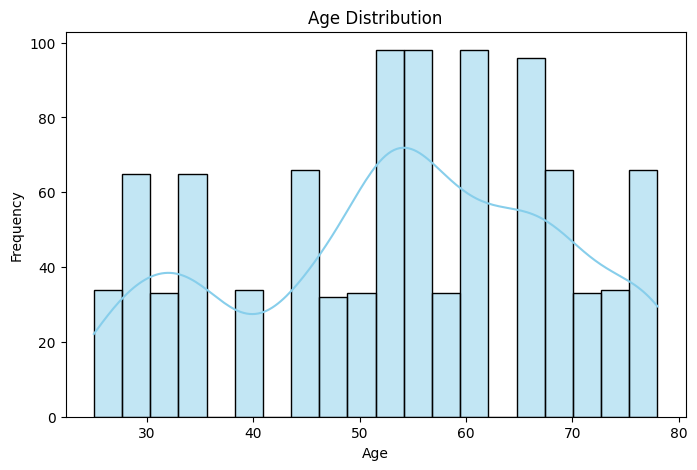

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Insight
* Most patients are concentrated within a specific age range.
* The age distribution helps identify whether the hospital primarily serves younger, middle-aged, or elderly patients.
* Any long tails or isolated bars may indicate outliers in patient age.

# Gender Distribution (Count Plot)

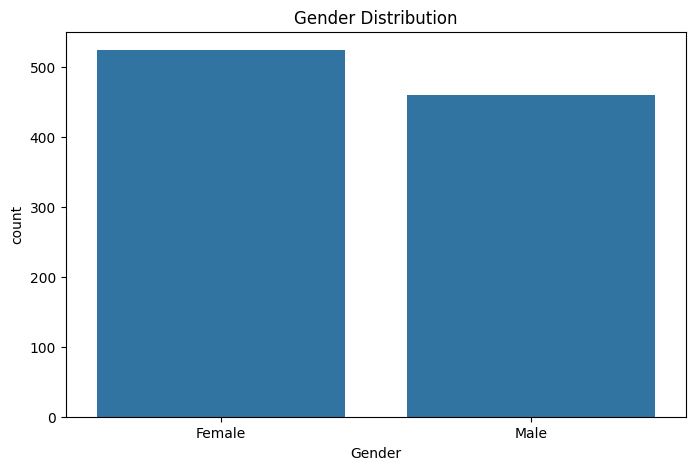

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender',data=df)
plt.title('Gender Distribution')
plt.show()

# Insight
* This visualization compares the number of male and female patients.
* A balanced distribution indicates equal representation, while a large difference may reflect demographic or healthcare access patterns.

#  Medical Condition Distribution

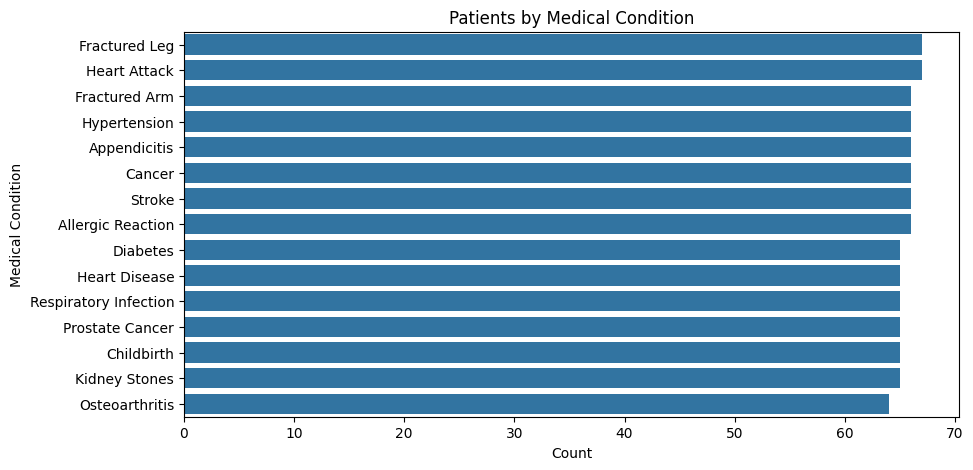

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='Condition',
              data=df,
              order=df['Condition'].value_counts().index)
plt.title("Patients by Medical Condition")
plt.xlabel("Count")
plt.ylabel("Medical Condition")
plt.show()

# Insight
* This chart identifies the most common medical conditions treated in the hospital.
* Frequently occurring diseases may require greater medical resources and specialized staff.

In [ ]:
df.columns


Index(['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ',
       'Admission_Date', 'Discharge_Date', 'Patient_State',
       'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome',
       'Satisfaction', 'Insurance_Claimed', 'Total_Cost'],
      dtype='object')

# Billing Amount Distribution

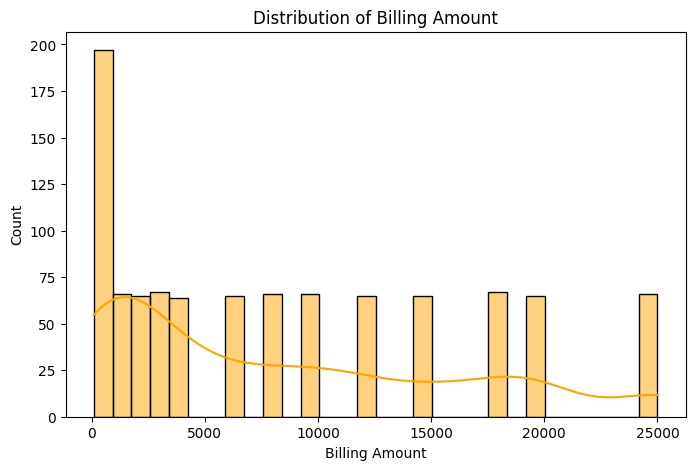

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Cost'],
             bins=30,
             kde=True,
             color='orange')

plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount")
plt.show()

# Insight
* Most patients fall within a specific billing range.
* Extremely high bills may indicate complex treatments or longer hospital stays.

# Patient State Distribution

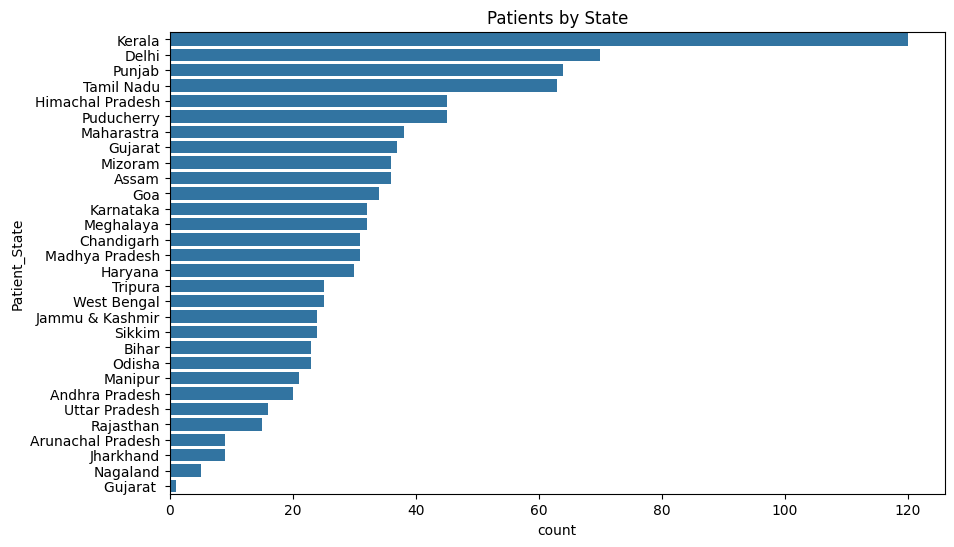

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Patient_State",
    data=df,
    order=df["Patient_State"].value_counts().index
)

plt.title("Patients by State")

plt.show()

# Insight
* This visualization shows which states contribute the highest number of patients.
* It can help hospitals understand their geographical service coverage.

# Length of Stay Distribution

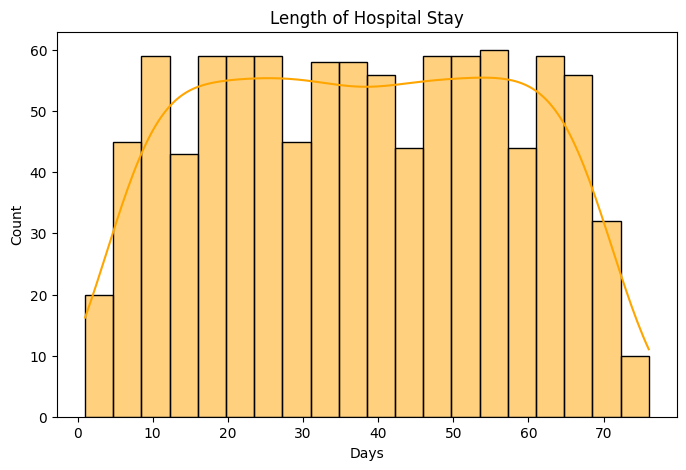

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(x='Length_of_Stay',data=df,bins=20,kde=True,color='orange')
plt.title('Length of Hospital Stay')

plt.xlabel("Days")

plt.show()

# Insight
* Most patients stay within a particular duration.
* Extremely long stays may indicate severe illnesses or treatment complications.

# Readmission Status

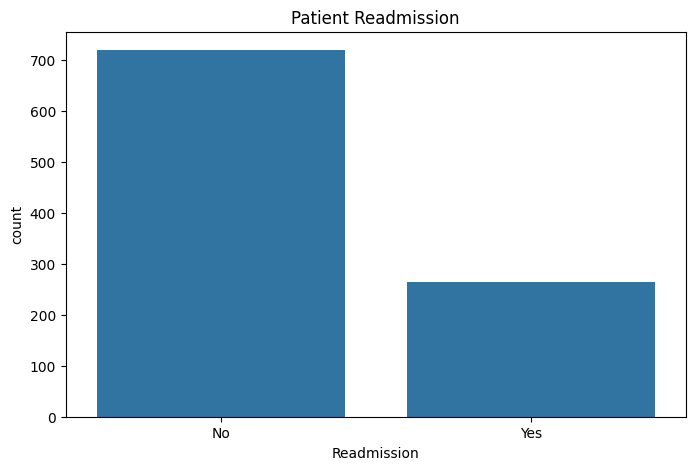

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Readmission',data=df)
plt.title('Patient Readmission')
plt.show()

# Insight
* This chart compares patients who were readmitted versus those who were not.
* High readmission rates may suggest the need to improve discharge planning or follow-up care.

# Patient Outcome

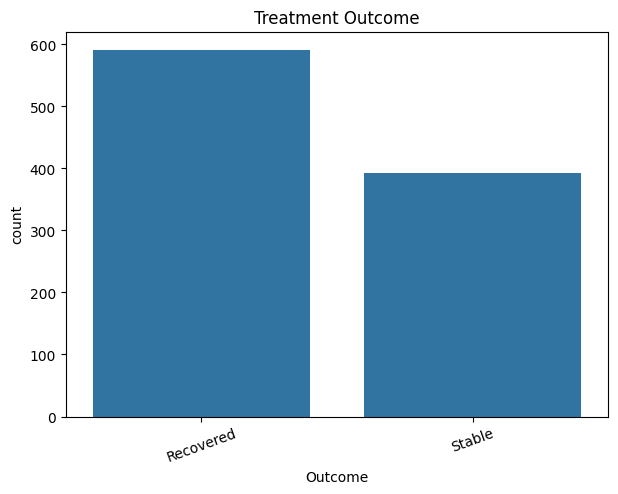

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="Outcome", data=df)

plt.title("Treatment Outcome")

plt.xticks(rotation=20)

plt.show()

# Insight
* The chart displays the outcomes of patient treatments.
* Comparing outcomes helps evaluate the effectiveness of hospital care.

# Satisfaction Score Distribution

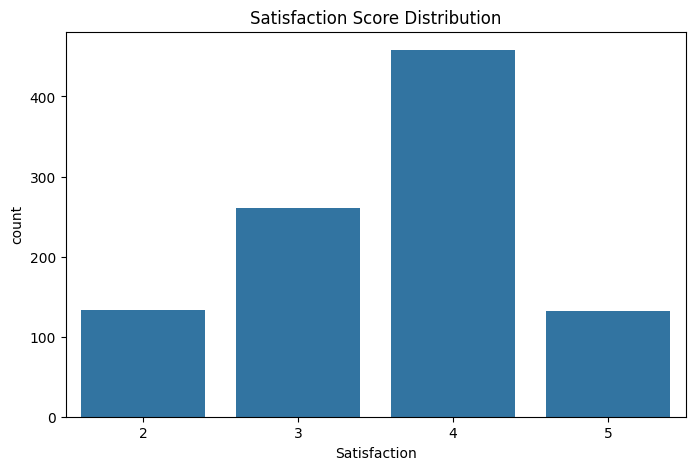

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Satisfaction',data=df)
plt.title('Satisfaction Score Distribution')
plt.show()

# Insight
* This visualization shows how satisfied patients were with hospital services.
* A higher concentration of positive ratings indicates better patient experience.

# Total Treatment Cost Distribution

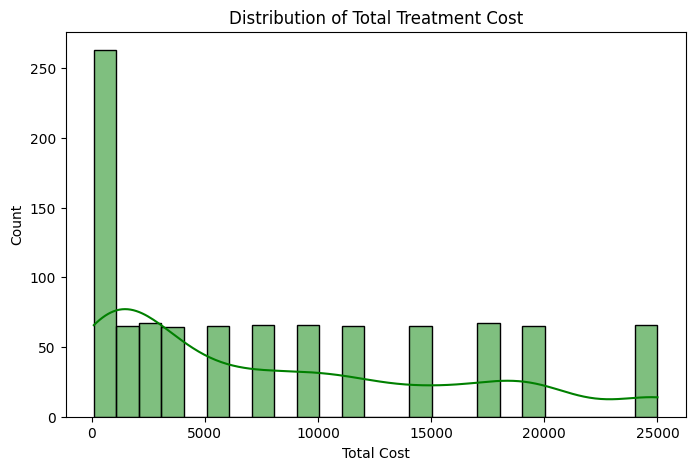

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Cost"],
             bins=25,
             kde=True,
             color="green")

plt.title("Distribution of Total Treatment Cost")

plt.xlabel("Total Cost")

plt.show()

# Insight
* This chart illustrates the distribution of treatment costs.
* Most patients typically fall within a common cost range, while very high-cost cases may represent complex treatments or extended hospital stays.

# Correlation Heatmap

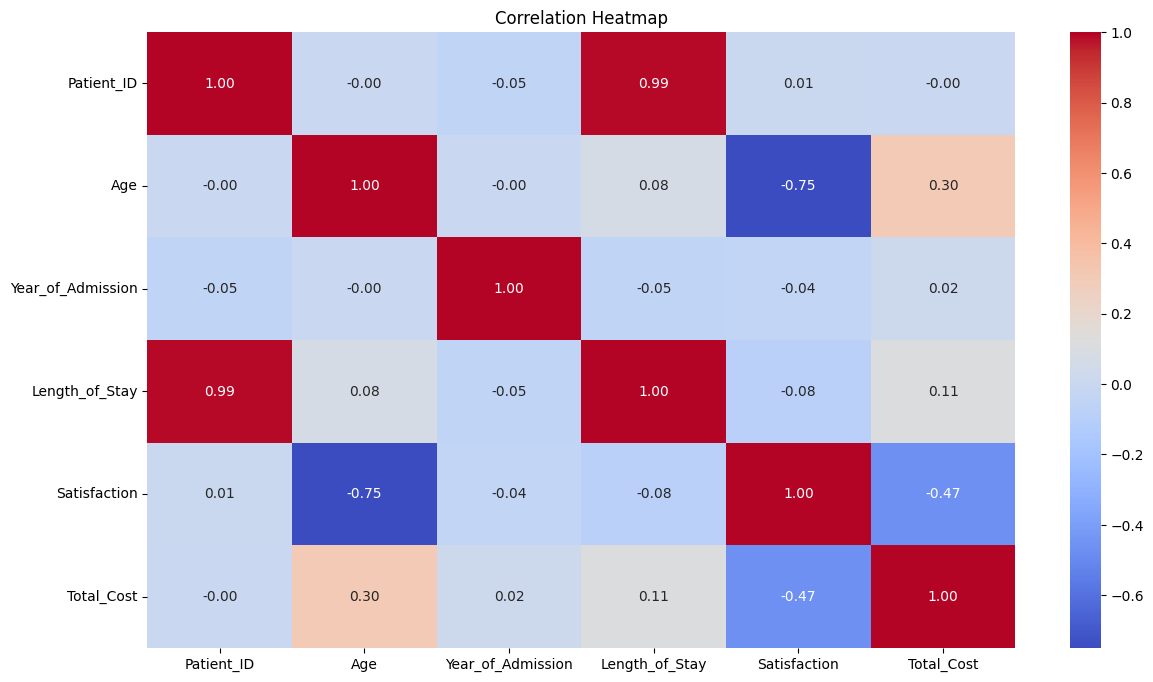

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Insight
* The heatmap highlights relationships between numerical variables.
* Strong positive correlations indicate variables that increase together, while negative correlations show inverse relationships.
* Weak correlations suggest that variables are largely independent.

# Step 9: Outlier Detection

# Boxplot for Age


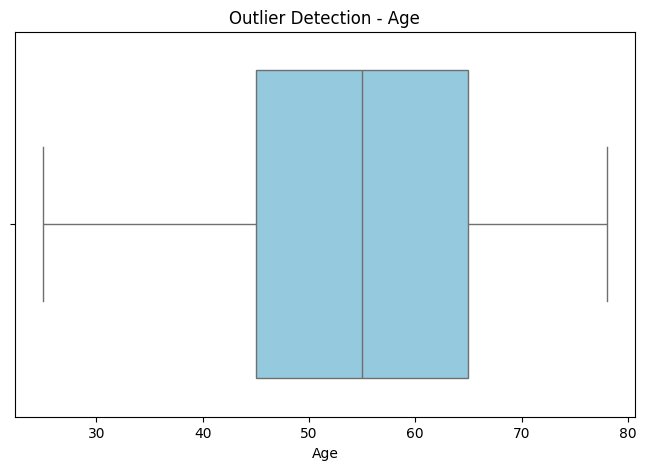

In [ ]:

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Age"], color="skyblue")

plt.title("Outlier Detection - Age")
plt.xlabel("Age")

plt.show()

Insight

* The boxplot identifies unusually young or old patients.
* Points outside the whiskers represent potential outliers that may require further investigation.

# Boxplot for Total Treatment Cost

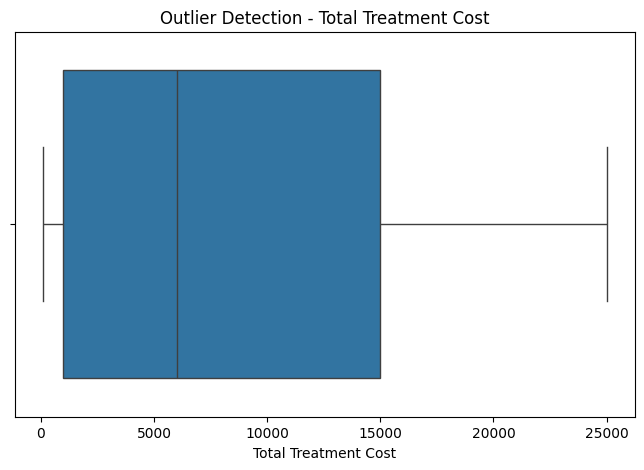

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Cost'])
plt.title('Outlier Detection - Total Treatment Cost')
plt.xlabel("Total Treatment Cost")

plt.show()

# Insight

* Extremely expensive treatments appear as outliers.
* These may correspond to critical illnesses, surgeries, or prolonged hospital stays.

# Boxplot for Length of Stay

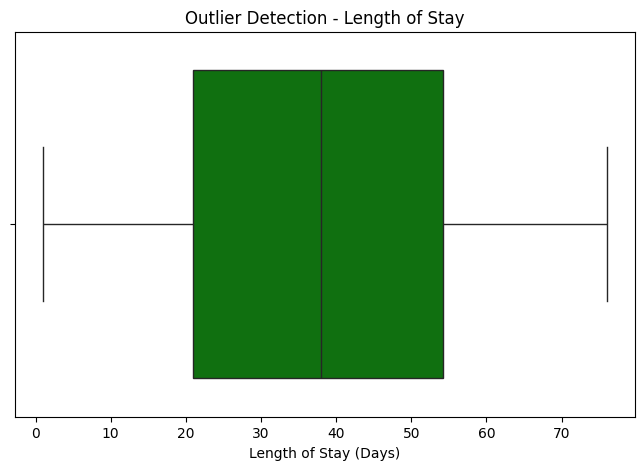

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Length_of_Stay"], color="green")

plt.title("Outlier Detection - Length of Stay")
plt.xlabel("Length of Stay (Days)")

plt.show()

# Insight

* Patients staying significantly longer than average are highlighted as outliers.
* Such cases may require special medical attention or involve complex conditions.

# Detect Outliers Using IQR Method

In [ ]:
# Detect Outliers using IQR

columns = ["Age", "Length_of_Stay", "Total_Cost"]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print("Number of Outliers:", outliers.shape[0])
    print("-"*40)

Age
Number of Outliers: 0
----------------------------------------
Length_of_Stay
Number of Outliers: 0
----------------------------------------
Total_Cost
Number of Outliers: 0
----------------------------------------


# Insight
* The Interquartile Range (IQR) method identifies observations that fall far below or above the normal range.
* A high number of outliers may indicate data entry errors, exceptional patient cases, or naturally occurring extreme values.
* Outliers should be examined carefully before deciding whether to retain or remove them.

# Step 10: Correlation Analysis

# Correlation Heatmap

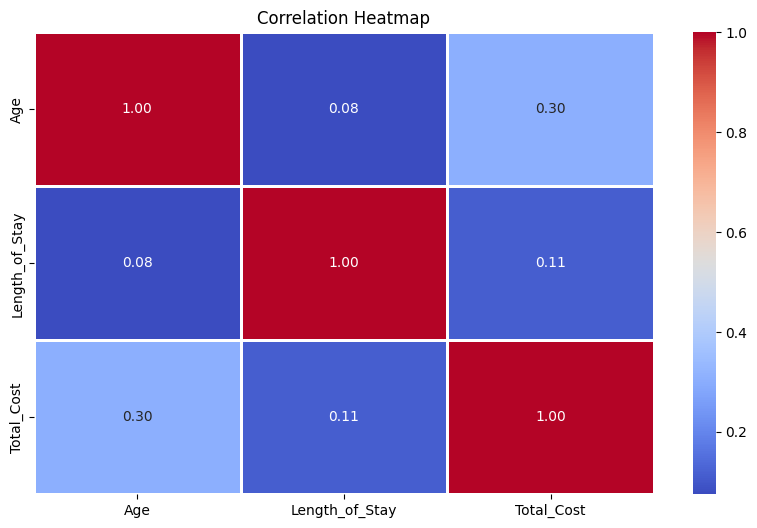

In [ ]:
plt.figure(figsize=(10,6))

corr = df[["Age","Length_of_Stay","Total_Cost"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Insight
* The heatmap illustrates the strength and direction of relationships between numerical variables.
* Correlation values close to +1 indicate a strong positive relationship, values close to −1 indicate a strong negative relationship, and values near 0 suggest little or no linear relationship.
* This analysis helps identify variables that tend to change together and can guide further investigation.

# Pairplot

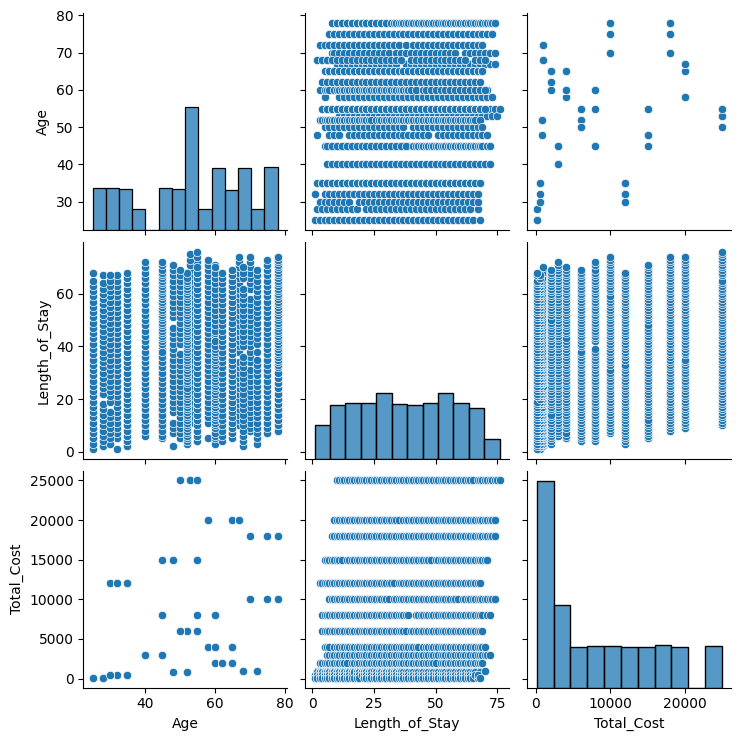

In [ ]:
sns.pairplot(
    df[["Age", "Length_of_Stay", "Total_Cost"]],
    diag_kind="hist"
)

plt.show()

# Insight
* The pairplot displays pairwise relationships among the selected numerical variables.
* Diagonal plots show each variable's distribution, while off-diagonal plots reveal trends, clusters, and potential outliers.
* It is useful for identifying patterns before building predictive models.

# Correlation Matrix

In [ ]:
corr_matrix = df[["Age", "Length_of_Stay", "Total_Cost"]].corr()

print("Correlation Matrix")
print(corr_matrix)

Correlation Matrix
                     Age  Length_of_Stay  Total_Cost
Age             1.000000        0.075080    0.303816
Length_of_Stay  0.075080        1.000000    0.114206
Total_Cost      0.303816        0.114206    1.000000


# Insight
* The correlation matrix provides the exact correlation coefficients between the selected numerical variables.
* Variables with higher absolute correlation values are more closely related, whereas values near zero indicate weak linear relationships.
* These results help determine whether factors such as age or hospital stay duration are associated with treatment costs.

# Final Conclusion
## Project Conclusion

* This project conducted a comprehensive Exploratory Data Analysis (EDA) on the Hospital Patient dataset to understand patient demographics, disease distribution, treatment patterns, medication usage, hospital stay duration, and treatment costs.

* The analysis included data cleaning, handling missing values, descriptive statistics, univariate, bivariate, and multivariate analysis, outlier detection, and correlation analysis. These steps provided valuable insights into the characteristics of the patient population and the operational aspects of healthcare delivery.

* Key findings revealed that patient admissions are concentrated within specific demographic groups, certain medical conditions occur more frequently than others, and treatment costs vary significantly across patients. Outlier analysis identified exceptional cases requiring further investigation, while correlation analysis showed that multiple factors collectively influence patient outcomes and healthcare expenses.

* Overall, this analysis demonstrates how data analytics can support evidence-based decision-making in healthcare. The insights generated can help hospital management improve resource allocation, optimize treatment planning, enhance inventory management, reduce operational costs, and deliver better patient care. Furthermore, the cleaned dataset provides a strong foundation for future predictive analytics and machine learning applications, making this project both business-oriented and technically valuable for a professional data analyst portfolio.